Model_2 cells: 12822
Model_1 cells: 9278
Using thresholds: SOX3 ≥ 9, SOX17A ≥ 5


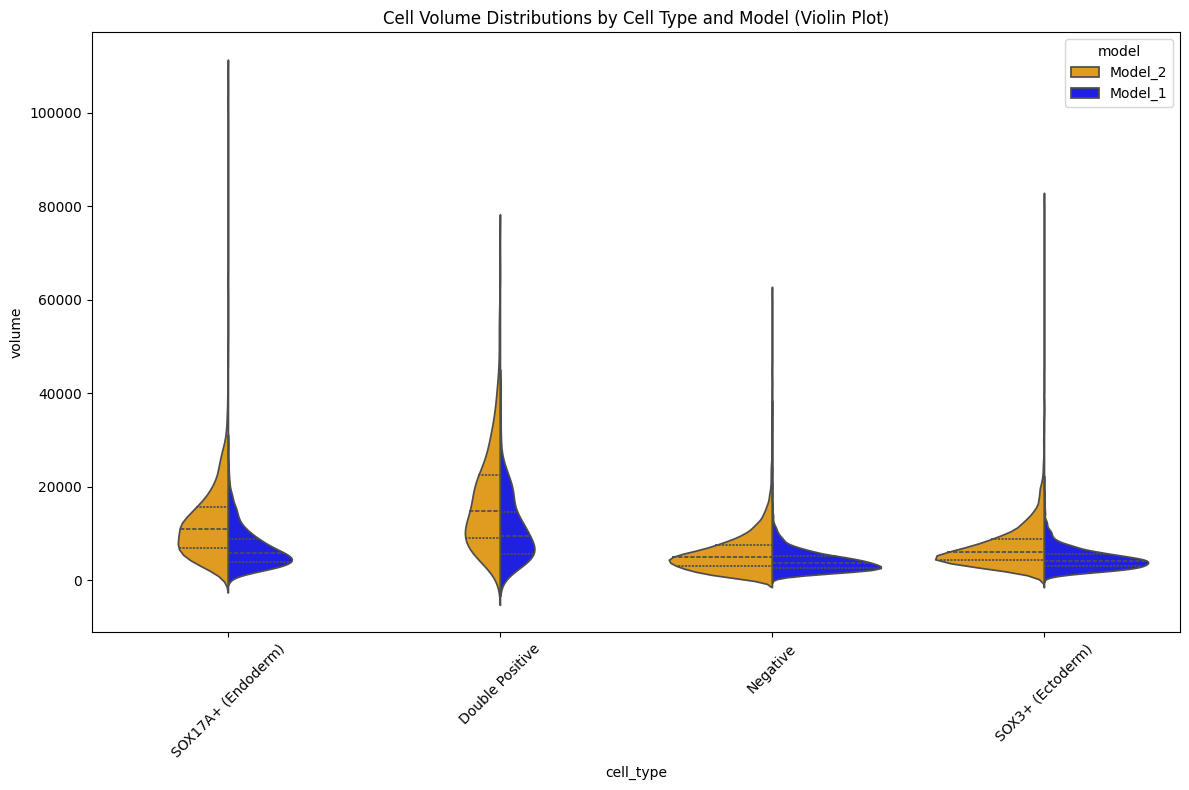

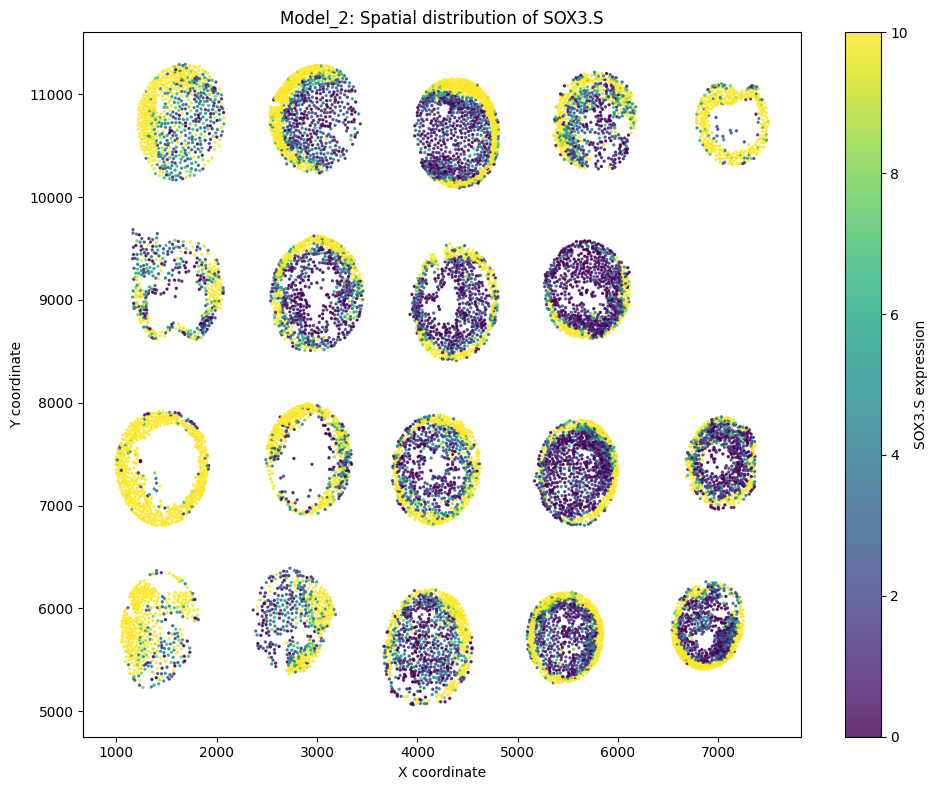

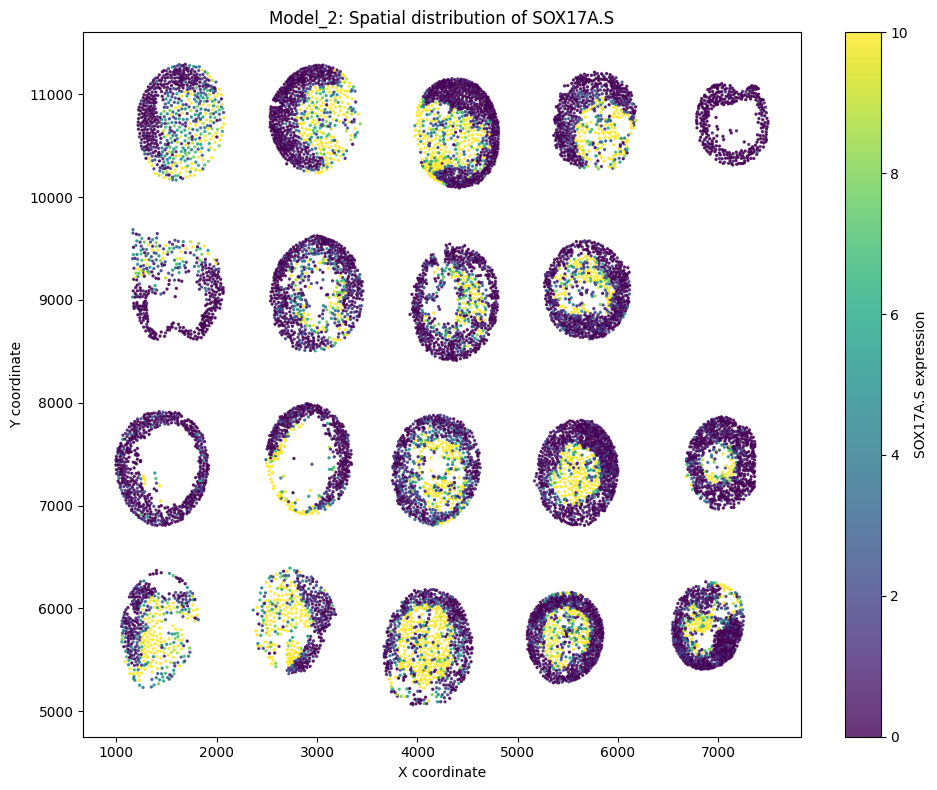

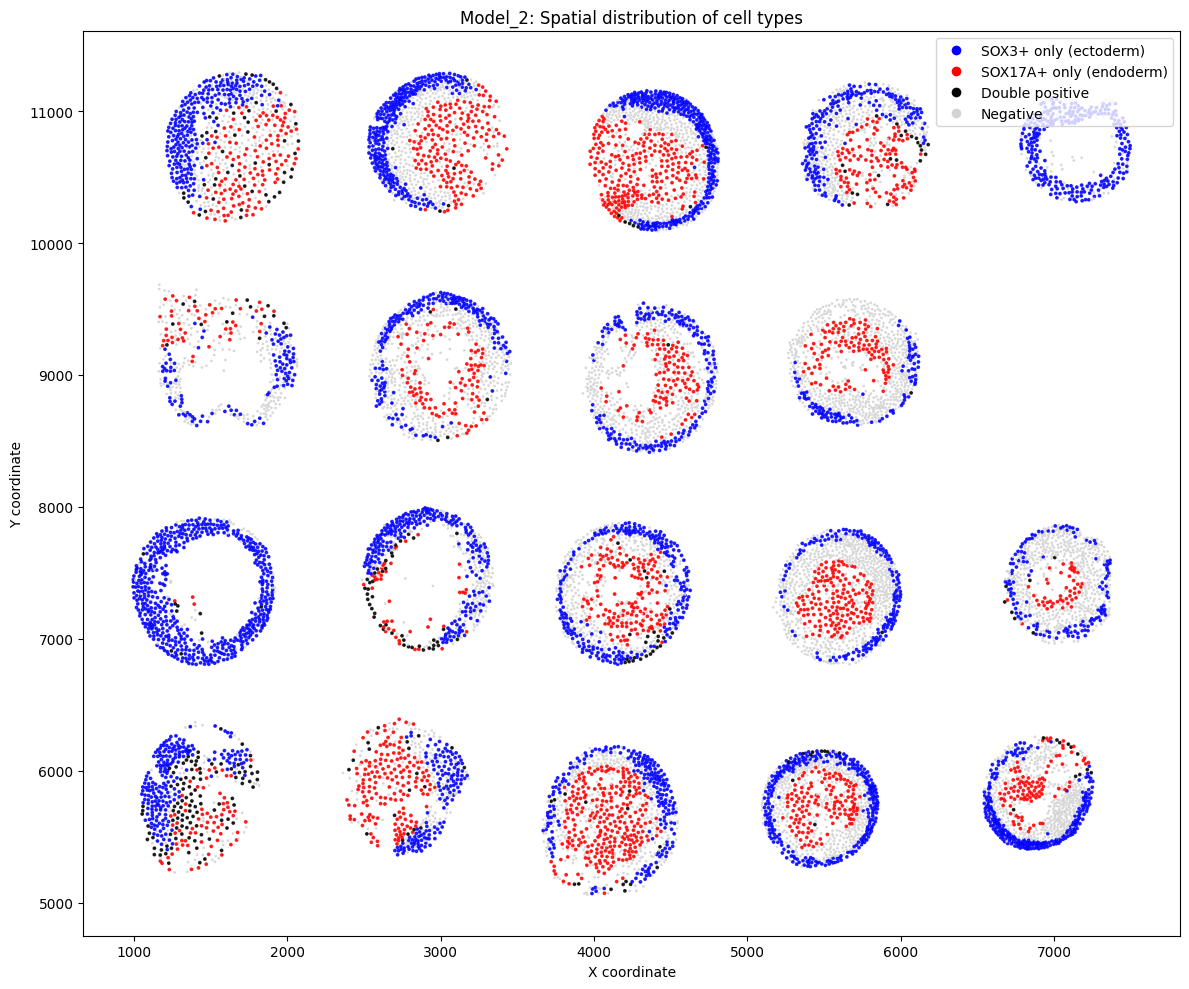

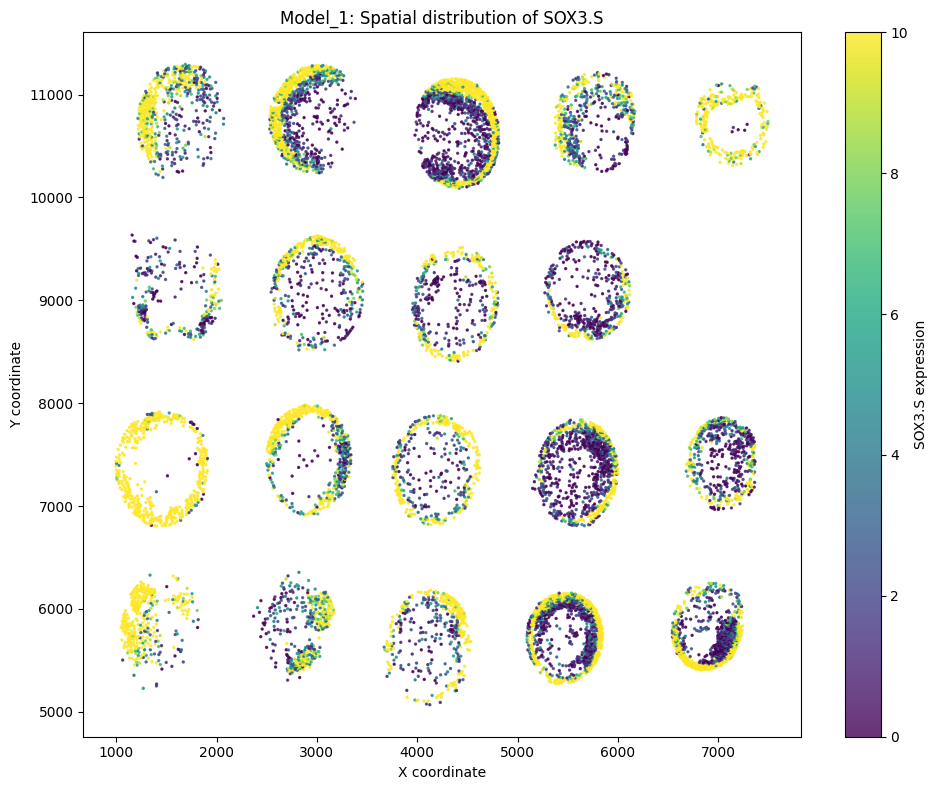

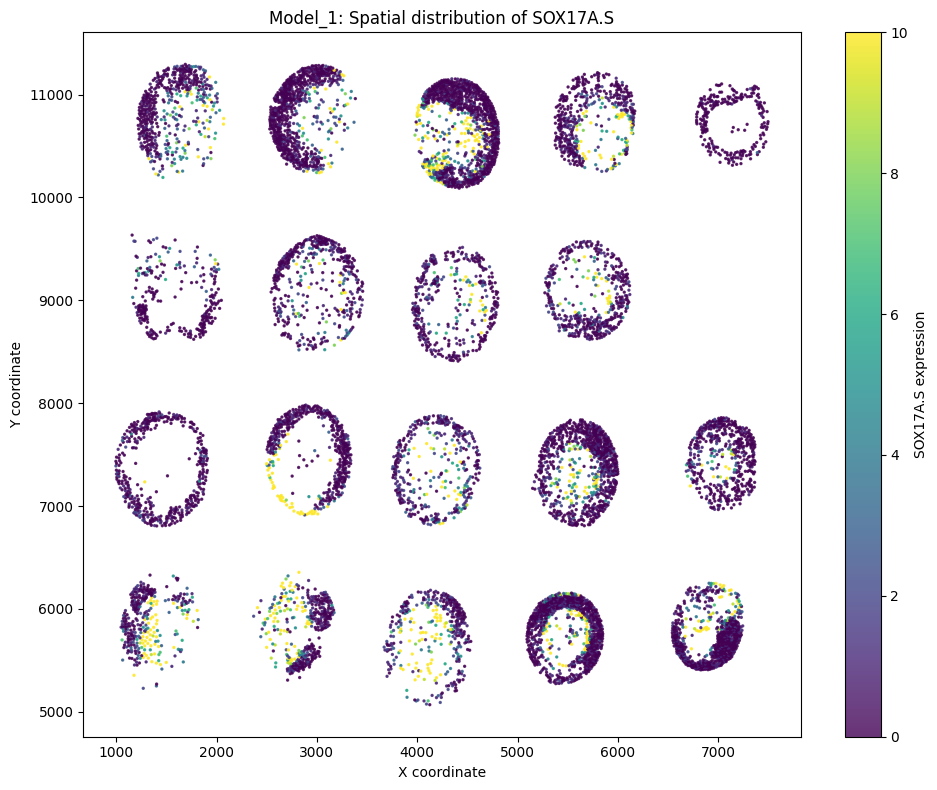

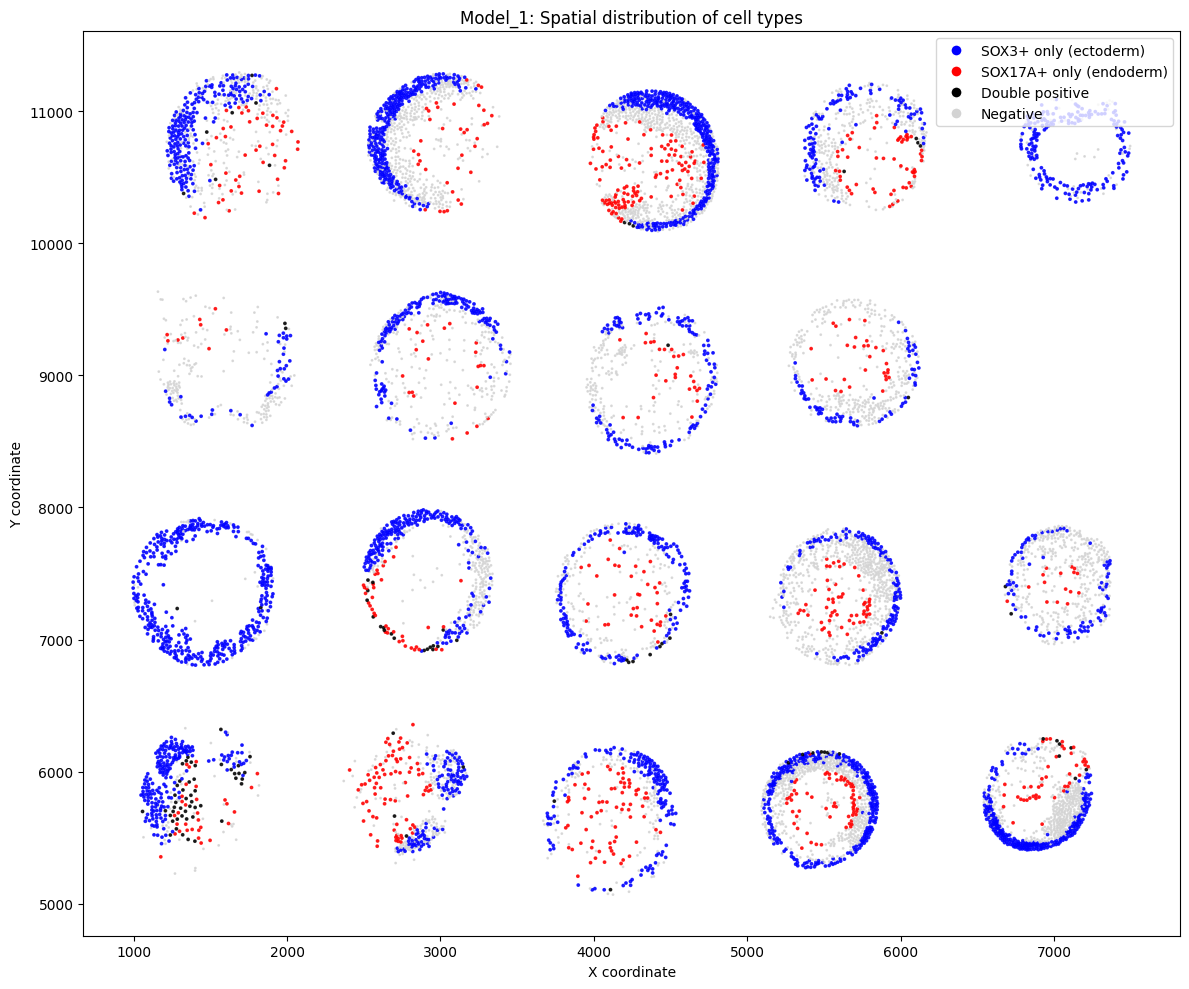

Model_1 cells in range: 9,177
Model_2 cells in range: 12,378


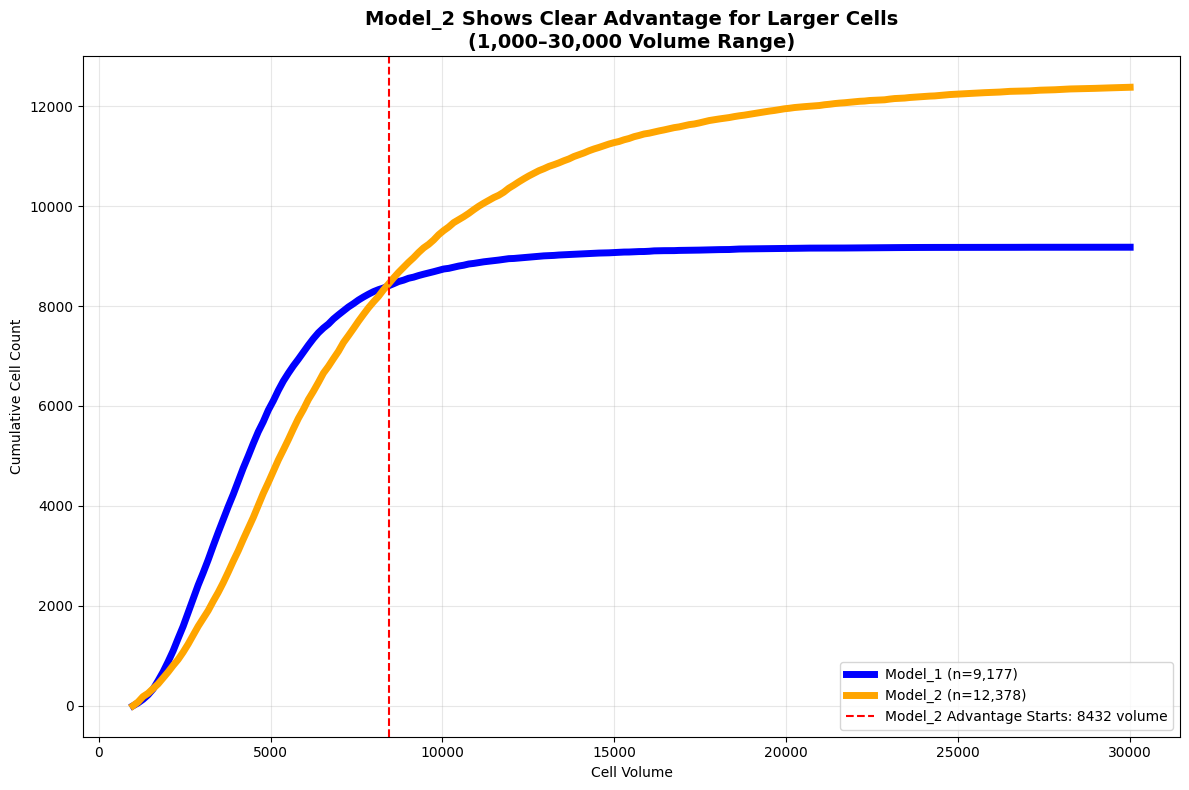

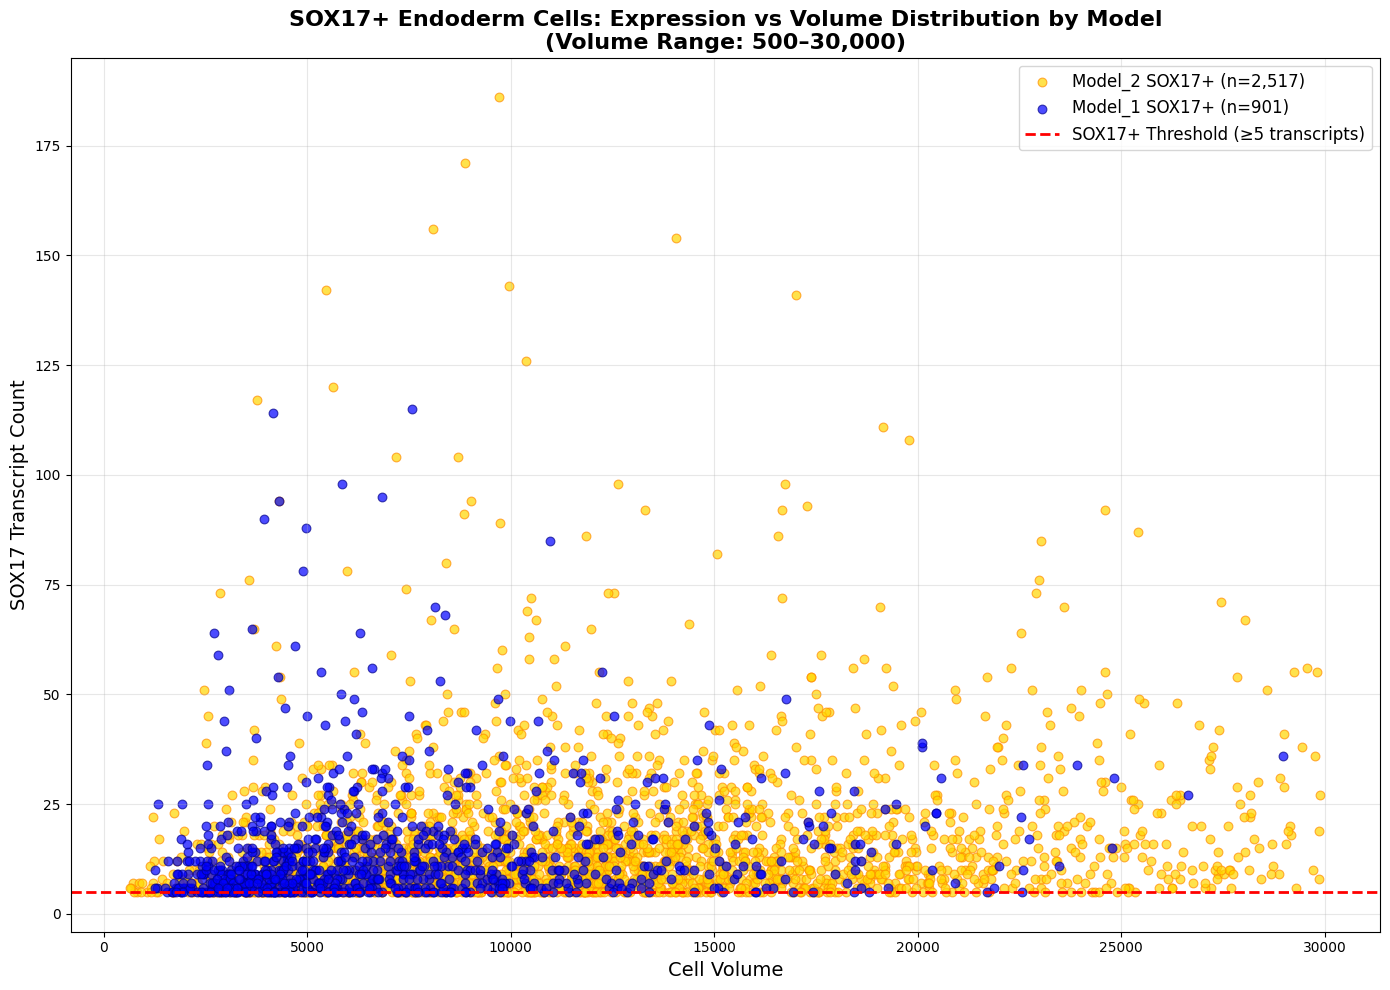


SOX17+ CELLS ANALYSIS BY VOLUME CATEGORY

--- Small/Medium (500–5k) ---
Model_1: 332/6094 SOX17+ cells (5.4%)
Model_2:     332/4807 SOX17+ cells (6.9%)
Ratio (Model_2/Model_1): 1.0x

--- Large (5k–10k) ---
Model_1: 367/2738 SOX17+ cells (13.4%)
Model_2:     775/4914 SOX17+ cells (15.8%)
Ratio (Model_2/Model_1): 2.1x

--- Very Large (>10k) ---
Model_1: 180/414 SOX17+ cells (43.5%)
Model_2:     1103/2468 SOX17+ cells (44.7%)
Ratio (Model_2/Model_1): 6.1x

SOX17+ CELLS VOLUME COMPARISON:
Model_1 SOX17+ cells: n=901, mean volume=7457.8
Model_2 SOX17+ cells: n=2517, mean volume=11916.8
Mann-Whitney U test: U=630632.0, p=0.000

Model_2 summary:
  Negative: 5920 (46.17%)
  SOX3+ (Ectoderm): 4300 (33.54%)
  SOX17A+ (Endoderm): 2250 (17.55%)
  Double Positive: 352 (2.75%)

Model_1 summary:
  Negative: 4919 (53.02%)
  SOX3+ (Ectoderm): 3456 (37.25%)
  SOX17A+ (Endoderm): 786 (8.47%)
  Double Positive: 117 (1.26%)


In [2]:

    
    
    
    
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
analyze_reduced_data.py
Load reduced CSVs, assign cell types based on SOX3 and SOX17A thresholds,
then generate all plots and statistics.
Model names: Chenxi → Model_1, SD → Model_2
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---------- Thresholds (adjustable) ----------
SOX3_THRESHOLD = 9
SOX17A_THRESHOLD = 5

def assign_cell_types(df):
    """Add a 'cell_type' column based on SOX3 and SOX17A thresholds."""
    sox3_pos = df['sox3_expression'] >= SOX3_THRESHOLD
    sox17a_pos = df['sox17a_expression'] >= SOX17A_THRESHOLD
    double_pos = sox3_pos & sox17a_pos

    cell_types = []
    for i in range(len(df)):
        if double_pos.iloc[i]:
            ct = 'Double Positive'
        elif sox3_pos.iloc[i]:
            ct = 'SOX3+ (Ectoderm)'
        elif sox17a_pos.iloc[i]:
            ct = 'SOX17A+ (Endoderm)'
        else:
            ct = 'Negative'
        cell_types.append(ct)
    df['cell_type'] = cell_types
    return df

# ----------------------------------------------------------------------
# Plotting functions (accept DataFrames with cell_type column)
# ----------------------------------------------------------------------
def plot_spatial_sox3(df, model_name):
    plt.figure(figsize=(10, 8))
    plt.scatter(df['x'], df['y'], c=df['sox3_expression'],
                cmap='viridis', s=2, alpha=0.8, vmax=10)
    plt.colorbar(label='SOX3.S expression')
    plt.title(f'{model_name}: Spatial distribution of SOX3.S')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.tight_layout()
    plt.show()

def plot_spatial_sox17a(df, model_name):
    plt.figure(figsize=(10, 8))
    plt.scatter(df['x'], df['y'], c=df['sox17a_expression'],
                cmap='viridis', s=2, alpha=0.8, vmax=10)
    plt.colorbar(label='SOX17A.S expression')
    plt.title(f'{model_name}: Spatial distribution of SOX17A.S')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.tight_layout()
    plt.show()

def plot_spatial_cell_types(df, model_name):
    colors = np.array(['lightgrey'] * len(df))
    sox3_pos = df['cell_type'] == 'SOX3+ (Ectoderm)'
    sox17a_pos = df['cell_type'] == 'SOX17A+ (Endoderm)'
    double_pos = df['cell_type'] == 'Double Positive'
    colors[sox3_pos] = 'blue'
    colors[sox17a_pos] = 'red'
    colors[double_pos] = 'black'
    sizes = np.ones(len(df)) * 1
    sizes[sox3_pos | sox17a_pos | double_pos] = 3

    plt.figure(figsize=(12, 10))
    plt.scatter(df['x'], df['y'], c=colors, s=sizes, alpha=0.8)
    plt.title(f'{model_name}: Spatial distribution of cell types')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
                   markersize=8, label='SOX3+ only (ectoderm)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                   markersize=8, label='SOX17A+ only (endoderm)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
                   markersize=8, label='Double positive'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
                   markersize=8, label='Negative')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_cumulative_volumes(df_model2, df_model1,
                            lower=1000, upper=30000,
                            label_model2='Model_2', label_model1='Model_1'):
    model2_clean = df_model2[(df_model2['volume'] >= lower) & (df_model2['volume'] <= upper)].copy()
    model1_clean = df_model1[(df_model1['volume'] >= lower) & (df_model1['volume'] <= upper)].copy()
    print(f"{label_model1} cells in range: {len(model1_clean):,}")
    print(f"{label_model2} cells in range: {len(model2_clean):,}")

    volume_thresholds = np.linspace(lower, upper, 200)
    model1_cum = [np.sum(model1_clean['volume'] <= t) for t in volume_thresholds]
    model2_cum = [np.sum(model2_clean['volume'] <= t) for t in volume_thresholds]

    plt.figure(figsize=(12, 8))
    plt.plot(volume_thresholds, model1_cum, color='blue', linewidth=5,
             label=f'{label_model1} (n={len(model1_clean):,})')
    plt.plot(volume_thresholds, model2_cum, color='orange', linewidth=5,
             label=f'{label_model2} (n={len(model2_clean):,})')

    crossover_found = False
    for i, (m1, m2) in enumerate(zip(model1_cum, model2_cum)):
        if m2 > m1 and not crossover_found and volume_thresholds[i] > 2000:
            crossover_vol = volume_thresholds[i]
            plt.axvline(x=crossover_vol, color='red', linestyle='--',
                        label=f'{label_model2} Advantage Starts: {crossover_vol:.0f} volume')
            crossover_found = True

    plt.xlabel('Cell Volume')
    plt.ylabel('Cumulative Cell Count')
    plt.title(f'{label_model2} Shows Clear Advantage for Larger Cells\n({lower:,}–{upper:,} Volume Range)',
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_sox17_vs_volume(df_model2, df_model1,
                         sox17_threshold=5,
                         vol_lower=500, vol_upper=30000,
                         label_model2='Model_2', label_model1='Model_1'):
    model2_clean = df_model2[(df_model2['volume'] >= vol_lower) & (df_model2['volume'] <= vol_upper)].copy()
    model1_clean = df_model1[(df_model1['volume'] >= vol_lower) & (df_model1['volume'] <= vol_upper)].copy()

    model1_sox17 = model1_clean['sox17a_expression']
    model2_sox17 = model2_clean['sox17a_expression']
    model1_volumes = model1_clean['volume']
    model2_volumes = model2_clean['volume']

    # ---- 1. Main scatter (expression vs volume) ----
    '''plt.figure(figsize=(12, 8))
    plt.scatter(model1_sox17, model1_volumes,
                alpha=0.6, s=30, color='blue', label=f'{label_model1} Model',
                edgecolors='white', linewidth=0.5)
    plt.scatter(model2_sox17, model2_volumes,
                alpha=0.6, s=30, color='gold', label=f'{label_model2} Model',
                edgecolors='black', linewidth=0.5)
    plt.axvline(x=sox17_threshold, color='red', linestyle='--', linewidth=2,
                label=f'SOX17+ Threshold (≥{sox17_threshold} transcripts)')
    plt.xlabel('SOX17 Transcript Count', fontsize=12)
    plt.ylabel('Cell Volume', fontsize=12)
    plt.title('SOX17 Expression vs Cell Volume by Segmentation Model', fontsize=14, fontweight='bold')'''

    model1_pos = np.sum(model1_sox17 >= sox17_threshold)
    model2_pos = np.sum(model2_sox17 >= sox17_threshold)
    '''plt.text(0.02, 0.98,
             f'{label_model1} SOX17+ cells: {model1_pos}/{len(model1_sox17)} ({model1_pos/len(model1_sox17)*100:.1f}%)',
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    plt.text(0.02, 0.88,
             f'{label_model2} SOX17+ cells: {model2_pos}/{len(model2_sox17)} ({model2_pos/len(model2_sox17)*100:.1f}%)',
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()'''

    # ---- 2. Focused scatter (SOX17+ only, same axes) ----
    model1_pos_mask = model1_sox17 >= sox17_threshold
    model2_pos_mask = model2_sox17 >= sox17_threshold

    '''plt.figure(figsize=(12, 8))
    plt.scatter(model1_sox17[model1_pos_mask], model1_volumes[model1_pos_mask],
                alpha=0.7, s=40, color='blue',
                label=f'{label_model1} SOX17+ (n={np.sum(model1_pos_mask)})',
                edgecolors='darkblue', linewidth=0.8)
    plt.scatter(model2_sox17[model2_pos_mask], model2_volumes[model2_pos_mask],
                alpha=0.7, s=40, color='gold',
                label=f'{label_model2} SOX17+ (n={np.sum(model2_pos_mask)})',
                edgecolors='darkorange', linewidth=0.8)
    plt.axvline(x=sox17_threshold, color='red', linestyle='--', linewidth=2)
    plt.xlabel('SOX17 Transcript Count', fontsize=12)
    plt.ylabel('Cell Volume', fontsize=12)
    plt.title('SOX17+ Endoderm Cells: Volume Distribution by Model', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()'''

    # ---- 3. Axes-exchanged scatter (Volume on X, SOX17 on Y) ----
    plt.figure(figsize=(14, 10))
    plt.scatter(model2_volumes[model2_pos_mask], model2_sox17[model2_pos_mask],
                alpha=0.7, s=40, color='gold',
                label=f'{label_model2} SOX17+ (n={np.sum(model2_pos_mask):,})',
                edgecolors='darkorange', linewidth=0.8)
    plt.scatter(model1_volumes[model1_pos_mask], model1_sox17[model1_pos_mask],
                alpha=0.7, s=40, color='blue',
                label=f'{label_model1} SOX17+ (n={np.sum(model1_pos_mask):,})',
                edgecolors='darkblue', linewidth=0.8)
    plt.axhline(y=sox17_threshold, color='red', linestyle='--', linewidth=2,
                label=f'SOX17+ Threshold (≥{sox17_threshold} transcripts)')
    plt.xlabel('Cell Volume', fontsize=14)
    plt.ylabel('SOX17 Transcript Count', fontsize=14)
    plt.title(f'SOX17+ Endoderm Cells: Expression vs Volume Distribution by Model\n'
              f'(Volume Range: {vol_lower:,}–{vol_upper:,})',
              fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---- Volume category analysis ----
    print("\n" + "="*60)
    print("SOX17+ CELLS ANALYSIS BY VOLUME CATEGORY")
    print("="*60)
    volume_categories = {
        'Small/Medium (500–5k)': (500, 5000),
        'Large (5k–10k)': (5000, 10000),
        'Very Large (>10k)': (10000, 20000)
    }
    for category, (vmin, vmax) in volume_categories.items():
        print(f"\n--- {category} ---")
        model1_mask = (model1_volumes >= vmin) & (model1_volumes < vmax)
        model1_total = np.sum(model1_mask)
        model1_pos = np.sum((model1_mask) & (model1_sox17 >= sox17_threshold))
        model2_mask = (model2_volumes >= vmin) & (model2_volumes < vmax)
        model2_total = np.sum(model2_mask)
        model2_pos = np.sum((model2_mask) & (model2_sox17 >= sox17_threshold))
        print(f"{label_model1}: {model1_pos}/{model1_total} SOX17+ cells ({model1_pos/max(model1_total,1)*100:.1f}%)")
        print(f"{label_model2}:     {model2_pos}/{model2_total} SOX17+ cells ({model2_pos/max(model2_total,1)*100:.1f}%)")
        if model1_pos > 0:
            print(f"Ratio ({label_model2}/{label_model1}): {model2_pos/model1_pos:.1f}x")

    # ---- Statistical comparison ----
    if np.sum(model1_pos_mask) > 0 and np.sum(model2_pos_mask) > 0:
        model1_vol_pos = model1_volumes[model1_pos_mask]
        model2_vol_pos = model2_volumes[model2_pos_mask]
        print(f"\nSOX17+ CELLS VOLUME COMPARISON:")
        print(f"{label_model1} SOX17+ cells: n={len(model1_vol_pos)}, mean volume={model1_vol_pos.mean():.1f}")
        print(f"{label_model2} SOX17+ cells: n={len(model2_vol_pos)}, mean volume={model2_vol_pos.mean():.1f}")
        stat, p_value = stats.mannwhitneyu(model1_vol_pos, model2_vol_pos, alternative='two-sided')
        print(f"Mann-Whitney U test: U={stat:.1f}, p={p_value:.3f}")
    else:
        print("\nNot enough SOX17+ cells for statistical comparison.")

def print_cell_type_summary(df, model_name):
    counts = df['cell_type'].value_counts()
    total = len(df)
    print(f"\n{model_name} summary:")
    for ct, cnt in counts.items():
        pct = cnt / total * 100
        print(f"  {ct}: {cnt} ({pct:.2f}%)")

# ----------------------------------------------------------------------
# Main execution
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Paths to the reduced CSV files
    reduced_model2_csv = "/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4C_S4B_S4C_S4D/reduced_Model_2.csv"
    reduced_model1_csv = "/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4C_S4B_S4C_S4D/reduced_Model_1.csv"

    # Load raw data
    df_model2 = pd.read_csv(reduced_model2_csv)
    df_model1 = pd.read_csv(reduced_model1_csv)

    # Assign cell types
    df_model2 = assign_cell_types(df_model2)
    df_model1 = assign_cell_types(df_model1)

    print(f"Model_2 cells: {len(df_model2)}")
    print(f"Model_1 cells: {len(df_model1)}")
    print(f"Using thresholds: SOX3 ≥ {SOX3_THRESHOLD}, SOX17A ≥ {SOX17A_THRESHOLD}")

    # Combine for violin plot
    combined_df = pd.concat([df_model2, df_model1], ignore_index=True)

    # ---------- 1. Violin plot ----------
    plt.figure(figsize=(12, 8))
    sns.violinplot(data=combined_df, x='cell_type', y='volume', hue='model',
                   palette={'Model_1': 'blue', 'Model_2': 'orange'},
                   split=True, inner="quartile")
    plt.title('Cell Volume Distributions by Cell Type and Model (Violin Plot)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ---------- 2. Spatial plots ----------
    plot_spatial_sox3(df_model2, "Model_2")
    plot_spatial_sox17a(df_model2, "Model_2")
    plot_spatial_cell_types(df_model2, "Model_2")

    plot_spatial_sox3(df_model1, "Model_1")
    plot_spatial_sox17a(df_model1, "Model_1")
    plot_spatial_cell_types(df_model1, "Model_1")

    # ---------- 3. Cumulative distribution (1000–30000) ----------
    plot_cumulative_volumes(df_model2, df_model1,
                            lower=1000, upper=30000,
                            label_model2='Model_2', label_model1='Model_1')

    # ---------- 4. SOX17 vs Volume (500–30000) ----------
    plot_sox17_vs_volume(df_model2, df_model1,
                         sox17_threshold=SOX17A_THRESHOLD,
                         vol_lower=500, vol_upper=30000,
                         label_model2='Model_2', label_model1='Model_1')

    # ---------- 5. Cell type summaries ----------
    print_cell_type_summary(df_model2, "Model_2")
    print_cell_type_summary(df_model1, "Model_1")
    
    
    
    